# Lesson 181 · RelBench v2 autocomplete

Mirror scope: real full F1 task/baseline reproduction and information-access contracts. Three live learner functions; original GNN model/trainer visible after EXIT. Fresh GNN training stopped at a numerical encoder prerequisite. This is author evidence, not your completed work.

Tier B: real relational F1 data embedded with hashes. Dependencies: Python3, numpy, pandas, pyarrow, duckdb and scikit-learn. The default lab needs no data downloads or cloud calls; install missing packages in your environment before running. Live Colab is NOT_CHECKED.

In [ ]:
# @colab-bootstrap
from pathlib import Path
import json,copy
import numpy as np
import pandas as pd
import pyarrow,duckdb,sklearn
print("L181: complete baseline replay; fresh GNN fit NOT_RUN; cloud $0")

**Your win:** turn “predict this missing cell” into an executable task contract: name the row, hide the answer, define legal context, and score the complete split. Read the core path in about 20 minutes; use another session for the lab.

**Observed:** complete two-task aggregation-baseline reproduction. Fresh GNN training **NOT_RUN_TRAINING_HEALTH_GATE**; the approved baseline-plus-GNN experiment **INCOMPLETE**. RelGT-AC numerical reproduction **NOT_RUN_SOURCE_GAPS**. New cloud/API spend **$0**. Learner: **PENDING_WRITTEN_DEFENSE**.

[Student notebook](https://avistian.github.io/relational/labs/0181-relbench-v2-autocomplete.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/html/0181-relbench-v2-autocomplete.html) · [Solution notebook](https://avistian.github.io/relational/labs/solutions/0181-relbench-v2-autocomplete.ipynb) · [Quick reference](https://avistian.github.io/relational/reference/relbench-v2-autocomplete.html) · [Reproduction protocol](https://avistian.github.io/relational/labs/l181-reproduction.md).

## 1 · A different question for the same database

[Lesson 180](https://avistian.github.io/relational/lessons/0180-public-encoder-checkpoint.html) asked what evidence establishes a public encoder fine-tune. Its practical exit remains **INCOMPLETE**. Here we start the research-frontier sequence by changing the prediction question. Exploring a new task does not complete that earlier gate.

**Forecasting** constructs a future outcome: for example, whether a driver fails to finish during the next 30 days. **Autocomplete** predicts an existing column value in a particular row while pretending that value has not been entered yet. The target is still available to the evaluator; it must be hidden from the predictor. **Supervised learning** uses those target values to train a prediction rule. That does not by itself establish foundation-model pretraining or transfer to another database.

> **In plain terms.** Forecasting asks “what happens next?” Autocomplete asks “what belongs in this blank?” Both require a precise account of what was knowable at prediction time.

RelBench v2 adds four databases: scholarly publications (`rel-arxiv`), enterprise orders (`rel-salt`), consumer reviews (`rel-ratebeer`), and clinical records (`rel-mimic`). Its new autocomplete tasks include binary, multiclass and numerical targets. We use the two published F1 numerical tasks to make the contract small enough to inspect completely. [Primary source: RelBench v2 §§2–4](https://arxiv.org/html/2602.12606v1#S4).

## 2 · Name the row before choosing the model

A **primary key** identifies a row. A **foreign key** points to a row in another table. A result row can link to a driver, race and constructor, but those linked entities are not interchangeable with the result row itself.

**Worked example.** Suppose result row 9001 belongs to driver 7 at time 10. The query is `(resultId=9001, time=10)`; the missing value is its finishing `position`. A second result for driver 7 has another result ID. A baseline grouped by result ID cannot retrieve driver 7's history merely because a driver foreign key exists.

The two real tasks use `resultId` and `qualifyId`, respectively. The complete query identity is **(row ID, timestamp)**. Our evaluator rejects duplicate, missing, extra or mismatched identities before calculating a score. Prediction file order is irrelevant.

| Task | Training rows | Validation rows | Test rows |
|---|---:|---:|---:|
| `results-position` | 8,997 | 1,400 | 4,798 |
| `qualifying-position` | 2,228 | 1,854 | 5,733 |

These reconstructed counts match paper Table 2. The cached database archive also matches the SHA256 digest in the publication-date source registry. A matching archive and count do not establish the historical training environment or seed identities.

**Exact split boundaries.** The pinned source uses `(database minimum, 2005-01-01 minus one second]`, `(2005-01-01, 2010-01-01 minus one second]`, and `(2010-01-01, database maximum]`, then removes missing targets. Parentheses exclude a boundary; a square bracket includes it. We retain these source predicates, including their boundary exclusions. The original implementation allocates a timestamp per second across decades; our bounded implementation passes the same minimum and maximum to SQL. Independent SQL checks all **25,010 retained labels**, and small dense-index tests verify the extrema calculation. [Pinned task builder](https://avistian.github.io/relational/labs/sources/l181/upstream/relbench/base/task_autocomplete.py).

## 3 · Hiding the answer is more than dropping one cell

A **proxy** here is a field the task designer excludes because it could reveal information unavailable when filling the target. Correlation alone is not a universal reason to remove a legitimate predictor. The exclusion list belongs to the specific task contract.

For `results-position`, the released contract drops `position` and seven named fields from **every result row**: `statusId`, `positionOrder`, `points`, `laps`, `milliseconds`, `fastestLap`, and `rank`. For `qualifying-position`, it removes qualifying `position` without additional named proxies. A **temporal cutoff** then limits dated context to the query time. Column removal and temporal filtering solve different problems. [Task registry](https://avistian.github.io/relational/labs/sources/l181/upstream/relbench/tasks/__init__.py), [database transformation](https://avistian.github.io/relational/labs/sources/l181/upstream/relbench/base/dataset.py).

**Worked example.** At query time 10, a past context row has position 2 and points 18. Whole-table removal hides both. A query-only mask leaves them in that context row. A row dated 11 is excluded regardless of whether its position is hidden.

<figure class="route-figure" tabindex="0">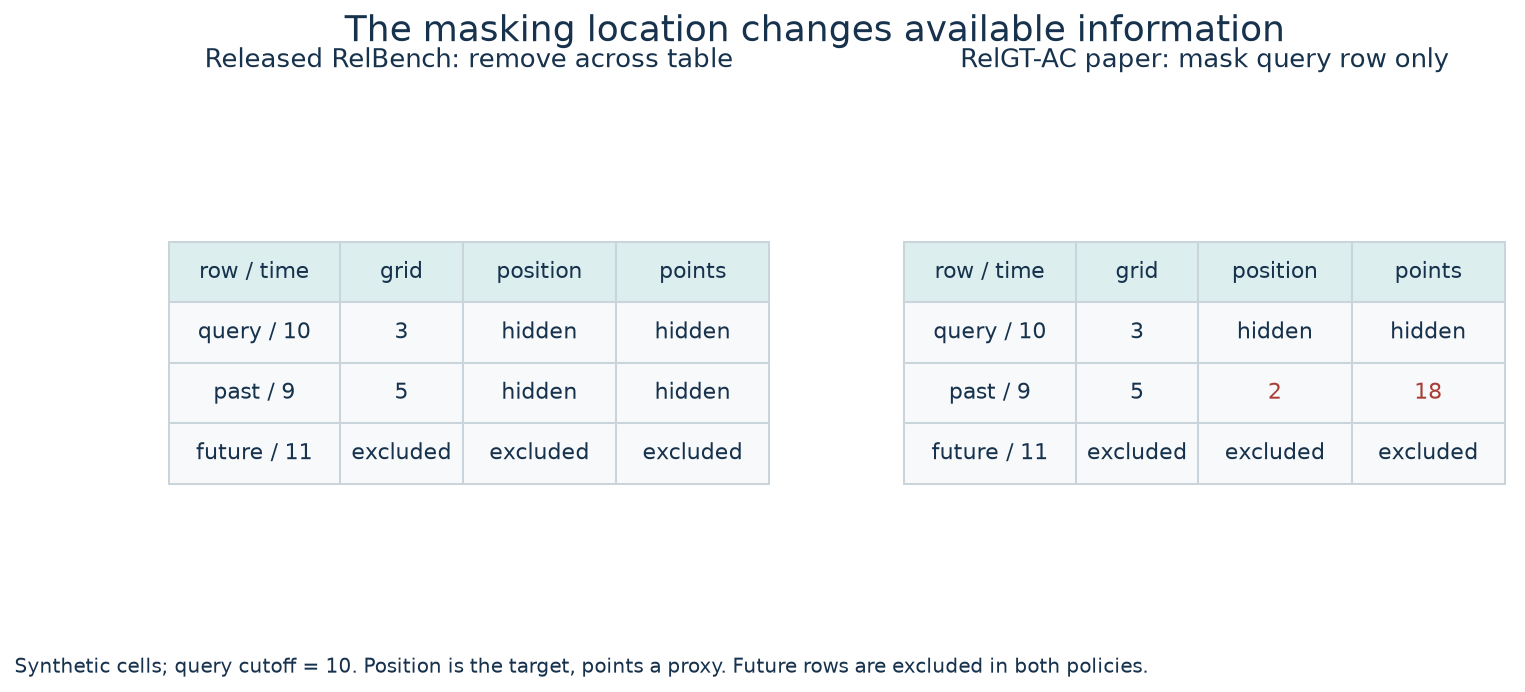<figcaption>Synthetic query and context rows under two masking policies. Future rows are excluded independently of target masking. Retained context targets change the information set.</figcaption></figure>

Try the visibility cases in the notebook below: keep query time 10, change context time 9→11, and compare global with seed_only masking.

Your first live notebook function implements this column-visibility rule. The full baseline audit calls it to verify the released global policy. The widget also illustrates a different policy, but changing the widget does not modify the measured experiment.

> **Scope check.** The source removes specified columns, not every conceivable proxy. Full event-availability auditing and sampled-neighborhood auditing remain unperformed after the training-health stop. Same calendar dates do not establish the within-day order in which race and qualifying information became available.

## 4 · Reproduce the simple models completely

Before training a graph model, reproduce the baseline meanings. **Global mean/median** predicts one fitted statistic for every query. **Entity mean/median** groups by the task's primary-key identity and uses zero for an unseen identity. **Global zero** always predicts zero. A driver-history aggregate would be an additional model, not the released entity baseline.

Predict before continuing: with no shared row IDs between fit and test, does entity mean retrieve driver history or use the zero fallback? Write your reason.

**Fit population matters.** The released script fits validation predictions on training labels. For test predictions it refits the aggregation baselines using training **plus validation** labels. No test labels enter the fitted statistic. Your second live notebook function receives the fitting rows explicitly, so the harness cannot hide this choice. [Released baseline script](https://avistian.github.io/relational/labs/sources/l181/upstream/examples/baseline_autocomplete.py).

**Mean absolute error (MAE)** is the average absolute prediction error, measured in finishing/qualifying places. Lower is better. **R²** compares squared error with always predicting the evaluation population's mean: `1 − sum((y − prediction)²) / sum((y − mean(y))²)`. Here `y` is the true position. Negative R² is possible. A constant learned from an earlier population need not equal the evaluation mean. That evaluation mean defines the metric denominator; it is not information passed to the predictor.

**Worked example.** Truth `[1, 3, 5]` and predictions `[2, 3, 4]` give MAE `2/3`. Squared error is `2`; the squared deviation from the truth mean `3` is `8`. R² is `1 − 2/8 = 0.75`. Your third function joins full query keys before applying these equations.

<figure class="route-figure" tabindex="0">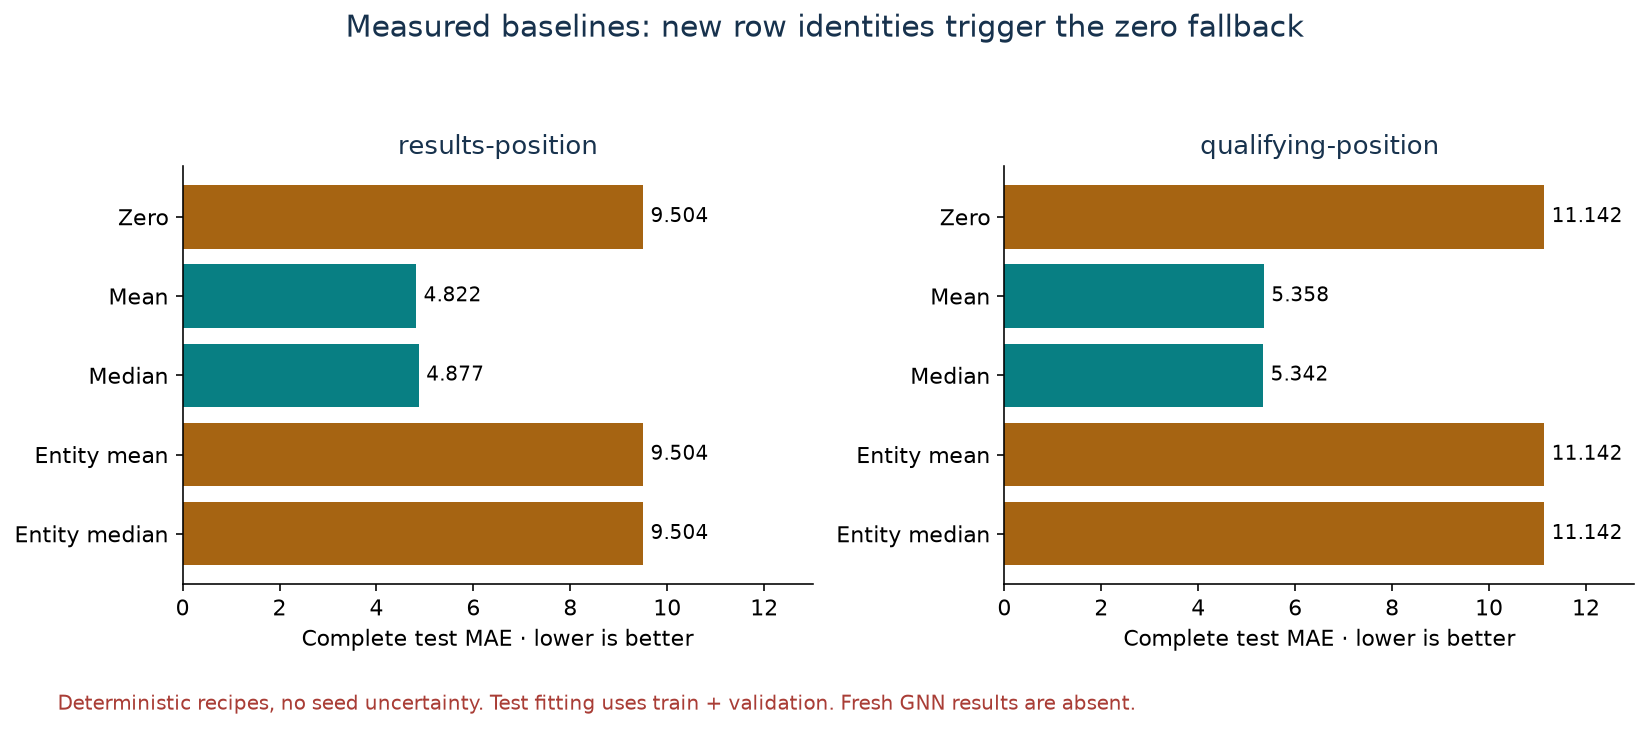<figcaption>Measured complete test MAE for all five deterministic recipes. The row-identity entity baselines fall back to zero; no GNN result or seed uncertainty is implied.</figcaption></figure>

| Task / test recipe | Measured R² | Measured MAE |
|---|---:|---:|
| results-position / global mean | -0.175775 | 4.822495 |
| results-position / global median | -0.218592 | 4.876615 |
| results-position / entity mean | -3.148348 | 9.504377 |
| qualifying-position / global mean | -0.001576 | 5.357594 |
| qualifying-position / global median | -0.000525 | 5.342055 |
| qualifying-position / entity mean | -3.214357 | 11.142334 |

Entity median equals entity mean here; both equal global zero. The full validation/test table is in the measured report.

All five recipes were evaluated on both complete validation and test populations: **68,925 predictions**. Independent SQL reconstructed every label, scalar aggregation regenerated every prediction, and scikit-learn independently checked every metric. All **40 comparisons** with the paper's rounded baseline MAE/R² values are within the predeclared `0.001` tolerance. These are deterministic recipes; repeated seeds would not create meaningful uncertainty bars.

**Work an unseen-identity baseline.** Fit on row IDs 100 and 101 with positions 1 and 3. Query different row IDs 200 and 201, whose true positions happen to be 1 and 3. The fitting mean is 2; neither query ID has a fitted entity group:

<table class="compact-trace" style="min-width:0;border-collapse:separate;border-spacing:3px"><thead><tr><th>Recipe</th><th>Predictions</th><th>MAE</th><th>R²</th></tr></thead><tbody><tr><td>Entity mean, unseen → 0</td><td>[0, 0]</td><td>2</td><td>−4</td></tr><tr><td>Global fitted mean</td><td>[2, 2]</td><td>1</td><td>0</td></tr></tbody></table>

For the first row, squared error is `1² + 3² = 10`; squared deviation from the query mean is `1² + 1² = 2`, so R² is `1 − 10/2 = −4`. Negative R² is valid. **Transfer check:** if both query truths become 2, that denominator is zero. This lesson's scorer rejects undefined R² instead of inventing a finite value; MAE can still be defined separately. These invented rows explain the metric, not another benchmark result.

The large entity-baseline errors are intelligible: zero primary-key overlap makes both entity recipes use the zero fallback. This result checks our understanding of task identity, rather than proving that relational history is useless.

## 5 · Model architecture: what the fresh GNN would train

A **node embedding** is a vector representing a row. The released model encodes numerical, categorical and timestamp features, then applies a four-layer row-level ResNet. ResNet adds intermediate representations through residual connections. The output contains 128 values per sampled row.

A **heterogeneous graph** distinguishes table and relation types. Two GraphSAGE layers sum neighboring messages within each foreign-key relation, transform self and neighbor representations, then sum relation outputs. Node-wise normalization and ReLU follow each layer. ReLU replaces negative coordinates with zero. Relative-time encodings tell the model how far context rows are from the query. Finally, a linear head turns the query embedding into one predicted position. [Full model](https://avistian.github.io/relational/labs/sources/l181/upstream/examples/model.py), [encoder and graph layers](https://avistian.github.io/relational/labs/sources/l181/upstream/relbench/modeling/nn.py).

<figure class="route-figure" tabindex="0">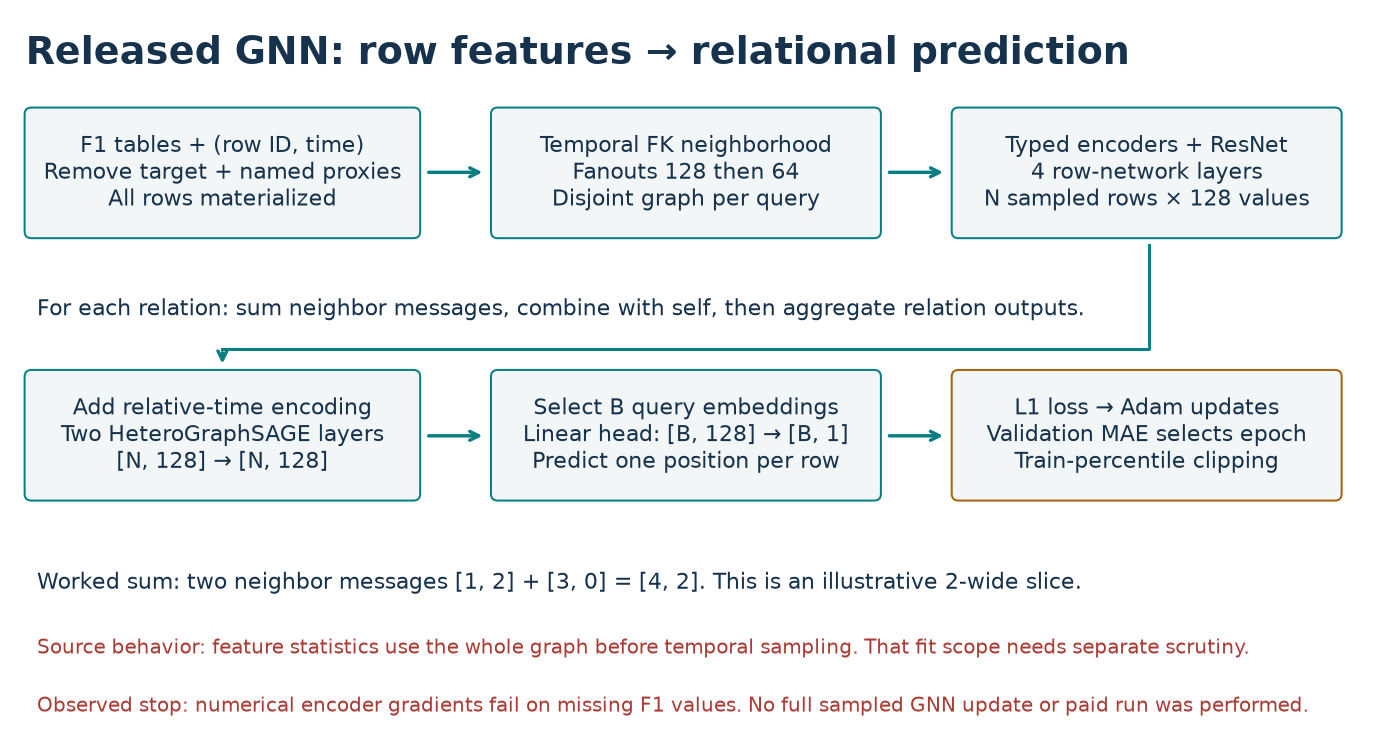<figcaption>Complete released GNN path and its source fitting boundaries. Shapes describe the intended model; no full sampled GNN update ran in L181.</figcaption></figure>

The approved experiment specified five seeds per task, ten epochs per seed, batch 512, width 128, Adam learning rate 0.005 and fanouts `[128, 64]`. An **epoch** traverses the training loader; a **fanout** limits sampled neighbors at a hop. L1 loss penalizes absolute training error. The lowest validation MAE selects the saved state, with the last tie winning in the source. Predictions are clipped to the training labels' 2nd–98th percentiles. Reported R² is not the checkpoint-selection metric. [Original trainer](https://avistian.github.io/relational/labs/sources/l181/upstream/examples/gnn_autocomplete.py).

**Why it stopped.** A gradient is the derivative used to update a weight. The pinned encoder's numerical path produced finite outputs but nonfinite weight gradients on real missing `circuits.alt` and `results` values. For the circuits probe, 3 missing altitudes produced 128 nonfinite weight-gradient entries. An independent direct `LinearEncoder` experiment reproduced that count. Missing values can enter a multiplication before the output is cleaned; a zero upstream derivative multiplied by NaN can still be NaN.

Replacing missing inputs before multiplication produced finite gradients in a diagnostic control. We did **not** substitute that repair into the full model. The probe used CPU PyTorch 2.13.0 and PyTorch Frame 0.3.0, permitted by the release's open-ended dependencies. It does not establish what happened in the authors' historical environment or in an unrun CUDA configuration. [Measured probe](https://avistian.github.io/relational/labs/evidence/l181/packet/gradient-preflight.json).

The source also materializes feature statistics over all database dates before temporal sampling. That is an additional fitting-scope concern: filtering sampled rows later does not undo statistics computed earlier. We have not established a full temporally valid training pipeline. Fresh GNN fitting stays **NOT_RUN_TRAINING_HEALTH_GATE**; the approved selected experiment stays **INCOMPLETE**.

## 6 · Read RelGT-AC as a research claim

RelGT-AC proposes query-row masking, a text encoder and a Transformer over relational context. **TF-IDF** weights words by their frequency in a row's text and their rarity across fitting documents. The paper uses 64 text features and projects them to 32 dimensions. A learned projection changes a vector's width. The experiment setup specifies 32 text dimensions, while equation 4 writes the general hidden width; without authenticated code that detail remains a source ambiguity. Table type, hop count, relative time and local degree are added to the feature representation. A **hop** traverses one graph edge; **degree** counts adjacent edges.

Local GraphSAGE combines nearby messages. **Attention** then gives sampled rows learned weights: compare query and key vectors, normalize scores with softmax so weights sum to one, and take a weighted sum of value vectors. Two Transformer layers use eight attention heads, which learn different comparisons. The query representation feeds a task-specific prediction head. Regression uses squared-error training; binary and multiclass tasks use cross-entropy losses that penalize wrong class probabilities. [RelGT-AC §§4–5](https://arxiv.org/html/2606.03040v1#S4).

<figure class="route-figure" tabindex="0">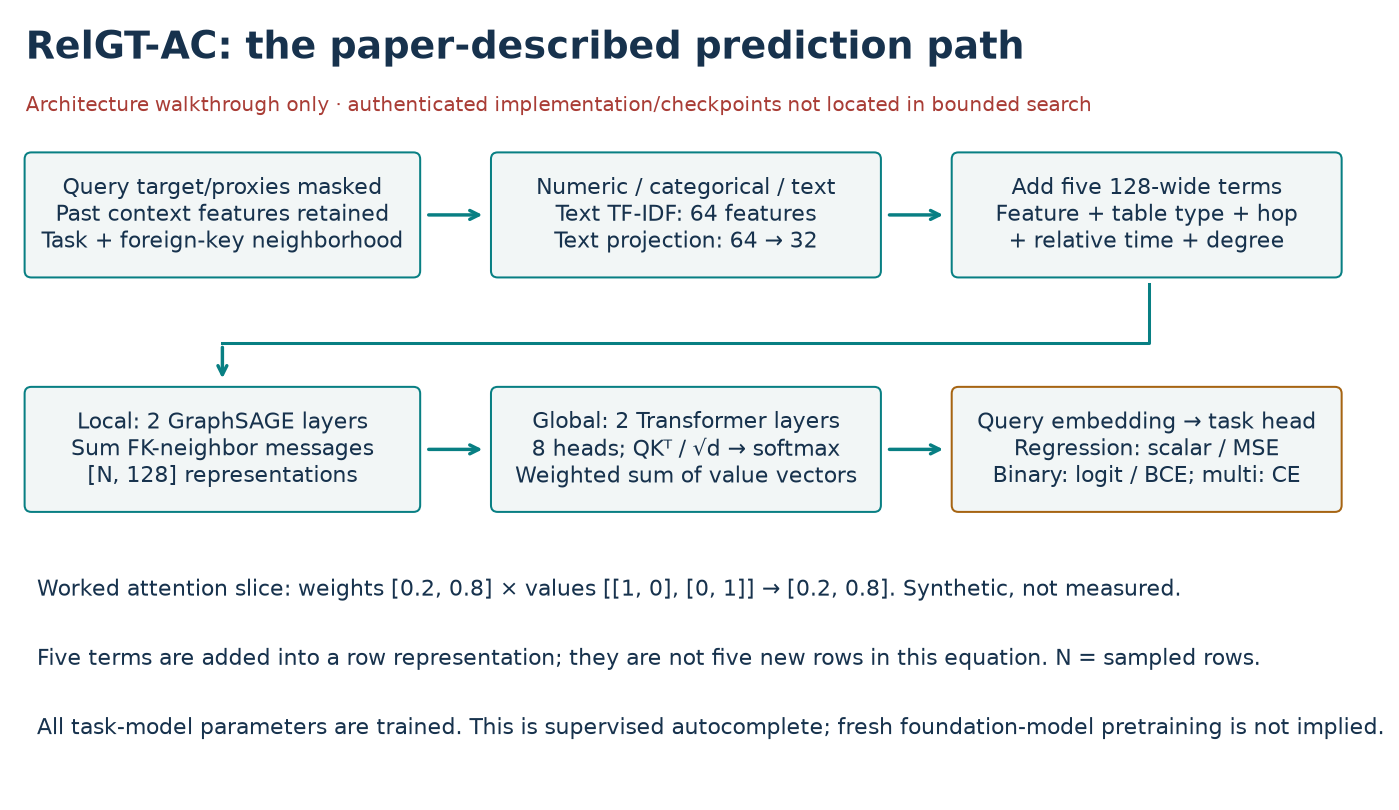<figcaption>Paper-described RelGT-AC architecture and an illustrative attention calculation. This is not authenticated implementation or executed model evidence.</figcaption></figure>

**Do not compare the wrong columns.** RelGT-AC's tables reuse RelBench **validation** numbers. Its reported F1 R² values `0.528` and `0.239` must not be compared as fresh test results against RelBench test values `0.394` and `0.015`. The paper-described seed-only masking also differs from the baseline's global removal. Before attributing a gain to attention, establish matched information access, split identities and selection procedures.

The paper states that code and checkpoints are released. In the recorded 2026-10-02 bounded search of the paper, author page and repository search results, we did not locate an authenticated RelGT-AC release. That is a search result, not proof of absence. The architecture here follows the paper and is not a validated reimplementation. Its numerical reproduction remains **NOT_RUN_SOURCE_GAPS**. [Search and protocol ledger](https://avistian.github.io/relational/labs/sources/l181/protocol-audit.json).

## 7 · Run, defend, retrieve

The default notebook authenticates an embedded real-data packet and reruns the complete baseline audit. It makes no cloud calls. The separately gated command verifies current packet hashes and stops before paid training:

```bash
.venv/bin/python labs/_budget_l181.py .venv/bin/python labs/_run_l181.py
# Expected exit 2: BLOCKED by the observed gradient prerequisite.
```

The complete original model/trainer is visible in the notebook appendix. The admission command and Modal local wrapper are tested gates; post-gate cloud training is **NOT_VALIDATED**. No pilot was dispatched. Actual new cloud/API spend is **$0**. The approved $10 aggregate cap, planned $8 stop and $2 reserve remain intact; changing missing-value handling would require a newly declared protocol.

**EXIT.** Implement the three functions, rerun all complete-key predictions, and submit a short defense: identify the task row, explain global versus query-only masking, justify the baseline fit populations, and state precisely which reproduction completed. Keep the GNN stop separate from the correct baseline results. Author preparation does not establish your mastery.

Write your defense in the EXIT fields and ask the teacher to review it.

**Primary reading:** [RelBench v2 §§2–4 and Tables 5/14/15](https://arxiv.org/html/2602.12606v1), alongside the pinned task builder and baseline script. Read RelGT-AC as the frontier comparison after the core contract is clear. Tomorrow, explain why entity mean predicts zero here without reopening this page. Ask the teaching agent about any unclear step or send your defense for feedback.

[Course sequence](https://avistian.github.io/relational/reference/curriculum.html) · [Measured report](https://avistian.github.io/relational/labs/evidence/l181/report.json) · [Paper comparison](https://avistian.github.io/relational/labs/evidence/l181/paper-comparison.json) · [Independent verification](https://avistian.github.io/relational/labs/_verify_l181_results.json).

**Next: [Lesson 182](https://avistian.github.io/relational/lessons/0182-rdb-pfn-composite-message-passing.html).** You can now state what information a model may use. Next, use that contract to ask whether combining two architectures changes the computation in a useful, testable way.


## PROVIDED · Authenticate the embedded data
SHA256 authenticates bytes. The packet contains all nine raw tables, all six task splits, all 20 prediction files, source excerpts and the observed gradient receipt. It does not contain a trained GNN.

In [ ]:
import base64,hashlib,io,zipfile
PACKET='...'
raw=base64.b64decode(PACKET)
assert hashlib.sha256(raw).hexdigest()=='e4a628e4a8ef575a2d3dbd91eb90eac85a3a0ebdb836cae41660be91da755406'
P=Path('l181-packet');P.mkdir(exist_ok=True)
with zipfile.ZipFile(io.BytesIO(raw)) as z:
    for name in z.namelist():assert not Path(name).is_absolute() and '..' not in Path(name).parts
    z.extractall(P)
manifest={'files': {'config.json': '3dd680c5af3e6aea99d7f9551dca1af67e38d78d4af8d45f39a22b98d2d95649', 'db/circuits.parquet': 'c36c6537b9c5c9985ec438110717e93289085a5bffbcee07d08bbe1771994d8d', 'db/constructor_results.parquet': '35582c2f0634d5503b664babf38264311332e6ca3cb612fb0fe737bfaffdc29e', 'db/constructor_standings.parquet': '739fc21ba301ef2081dbd8e56d643f148b672224a4d223b95d6107ccd735aa6b', 'db/constructors.parquet': 'fc79dd346430186cdca6263e1c532891bf4d4ba7463fd94b398350a9356180c6', 'db/drivers.parquet': 'ba3461b83a1a467a856bde4059519140a5a31952ad24a5e944ea9dd5c5faceae', 'db/qualifying.parquet': '2d5cb7b4ed6cf4076b74ab1cc79f5f35faf31b7f032b51d2a1ac814e1d0c834b', 'db/races.parquet': '88bb260f03c9ec5c7b030969d7284531d5f8e8592d73174686ad01cdfc8f87ea', 'db/results.parquet': 'b8b0e39b27f318a7bd461f21bb0ba9ef44909ed569d287e0c6b2969c6bd2f598', 'db/standings.parquet': 'f3f6a34fee190f077f2fe48026a7e5659e4c91a34f72340cdff3cf407c1f3534', 'gradient-preflight.json': 'e350d556d073446d72f5743b5e4a82f429bc63bea324593ad666d72ab0a35e0a', 'qualifying-position/test-entity_mean.parquet': '9afb5bf37530510f9ed9f74b9c5a54ccf2ad34c87b17ea41aed7c20de82670d4', 'qualifying-position/test-entity_median.parquet': '9afb5bf37530510f9ed9f74b9c5a54ccf2ad34c87b17ea41aed7c20de82670d4', 'qualifying-position/test-global_mean.parquet': '51788c401843eef6394cd619324183d7e65b057669bffe1f44e7886dff5c443a', 'qualifying-position/test-global_median.parquet': 'ad8165e0620dbeda8b722401eb0b2909bdb9d323aad99ae548e59747575ad134', 'qualifying-position/test-global_zero.parquet': '9afb5bf37530510f9ed9f74b9c5a54ccf2ad34c87b17ea41aed7c20de82670d4', 'qualifying-position/test.parquet': 'ab0d0e1431f8eaa921c0e97ad84b461aa5a0d28ae0a4f59c911012f3f0aa615a', 'qualifying-position/train.parquet': '8b4aff4890131654427c8823d1e11c10dfc03f84d12cf24c7be85e8e39d24813', 'qualifying-position/val-entity_mean.parquet': 'c3caf53407b56102b1c682cb910d1dac51dedc8159230b481dd0fec3b078aa33', 'qualifying-position/val-entity_median.parquet': 'c3caf53407b56102b1c682cb910d1dac51dedc8159230b481dd0fec3b078aa33', 'qualifying-position/val-global_mean.parquet': '994952e2db32baab7b20a114717eb2e14404f313c446a58f70583920144de950', 'qualifying-position/val-global_median.parquet': 'ffd5550c0d9f04c11432708dcd70f0ce321c6747d92470dde1bcc511908a2592', 'qualifying-position/val-global_zero.parquet': 'c3caf53407b56102b1c682cb910d1dac51dedc8159230b481dd0fec3b078aa33', 'qualifying-position/val.parquet': '4250ae557a79442880bee4ed3865d385e23c833543b456715a24e34ffa8cc39a', 'qualifying-position-circuits-gradient-input.parquet': '2f8987972051b9fbc4eb4ef1e6baae6c857671ba361740101daf4d69f84b037e', 'qualifying-position-results-gradient-input.parquet': '73c6567219edb0877c04f6dcd0a01bdffd761af863f51cdb3c12920fa3db55eb', 'results-position/test-entity_mean.parquet': '5a86e5b741c94829d5c37fd8d8683e317f1c8ac00ac05df0402a877fa42830e1', 'results-position/test-entity_median.parquet': '5a86e5b741c94829d5c37fd8d8683e317f1c8ac00ac05df0402a877fa42830e1', 'results-position/test-global_mean.parquet': 'ace5180b162b09b606c196356e11443161df38270b203f3a6acaf1f5acdb7ca5', 'results-position/test-global_median.parquet': '2ebd6952d8d8d0fb31e8a6a4155648cacd1a10faead14d5f2f53642c90ad396c', 'results-position/test-global_zero.parquet': '5a86e5b741c94829d5c37fd8d8683e317f1c8ac00ac05df0402a877fa42830e1', 'results-position/test.parquet': '7bba22959dd0791510b113e6e01c42025662b2c762833188eff786fac3c77154', 'results-position/train.parquet': '07455729c32ec0ff4f126938e3f2b52d09e4f7961617396c1b6366145dace345', 'results-position/val-entity_mean.parquet': '375cddcc31a0532b1c75cb98e505028754b834fd70299a5a0f1f43b4abc86989', 'results-position/val-entity_median.parquet': '375cddcc31a0532b1c75cb98e505028754b834fd70299a5a0f1f43b4abc86989', 'results-position/val-global_mean.parquet': 'a9b0d1514629dfffec97772ed3f586884075642f4c47d3d5d9802aeb7ff093e4', 'results-position/val-global_median.parquet': '9f9c703a60df6903e7f58be5ae79b4e3b3d5b0f499d4c414a1d7f635a129439b', 'results-position/val-global_zero.parquet': '375cddcc31a0532b1c75cb98e505028754b834fd70299a5a0f1f43b4abc86989', 'results-position/val.parquet': 'bde68264092ebd27866695517cc253689659c8b425bf3dbb834e8f094bb8c3b3', 'results-position-circuits-gradient-input.parquet': '2f8987972051b9fbc4eb4ef1e6baae6c857671ba361740101daf4d69f84b037e', 'results-position-results-gradient-input.parquet': '1e269f5b9780a3abe1127f8e401daf52b936b935d969deedbc9aa53ef88e6762', 'source/examples/baseline_autocomplete.py': 'c4e3e5b201d8119a11d248f0af404054651785a76f00fcd825d0ec0a1293c07e', 'source/examples/gnn_autocomplete.py': 'a6377634300870d1f37efe7a42f10e5e512664ec5923ee20f335c66f703c2460', 'source/examples/model.py': '815c2eb6a5957c57112755950c728a17a210d6b5187ae4d562343fe389f59004', 'source/relbench/base/dataset.py': 'b8842959993df20cca496a8d16044db6624db6d99ea1fa306518b4f425750e4d', 'source/relbench/base/task_autocomplete.py': 'd42376c6d69f6c645e1d52eeb10daea36a78863461bed9cff62ca03c59fc92e1', 'source/relbench/modeling/graph.py': 'bc200585fcdfbe31aef459a0241bb0fcb97aa31cf1023f8aff3e68420fc2b976', 'source/relbench/modeling/nn.py': '235bbd234c24d40e4180199513a867f4525751df667cb09471ae40e01f81771b'}}
print('Authenticated packet:',len(manifest['files']),'files')

## TODO · Hide the intended cells
Return columns in original order. For policy global, hide target and proxies in every row. For seed_only, hide them only when seed is true. Reject unknown policies or duplicate column names. This function does not filter rows by timestamp; keep that separate.

In [ ]:
def visible_columns(columns, target, proxies, seed, policy):
    raise NotImplementedError("Implement visible_columns")

### CHECK · Hide the intended cells
A passing toy check is preparation for the full-population audit below.

In [ ]:
assert visible_columns(['position','points','grid'],'position',['points'],False,'global')==['grid']
assert visible_columns(['position','grid'],'position',[],False,'seed_only')==['position','grid']
print('Immediate CHECK passed')

## TODO · Make fitting scope explicit
fit contains entity,time,y; query contains entity,time. Return a NumPy float prediction array in query order for global_zero, global_mean, global_median, entity_mean or entity_median. Group entity recipes by entity only; unseen entities use zero. Reject unknown recipes and empty/nonfinite fit labels. The caller chooses train versus train+validation.

In [ ]:
def baseline_predictions(fit, query, kind):
    raise NotImplementedError("Implement baseline_predictions")

### CHECK · Make fitting scope explicit
A passing toy check is preparation for the full-population audit below.

In [ ]:
fit=pd.DataFrame({'entity':[1,1,2],'time':[1,2,1],'y':[2.,8.,11.]})
query=pd.DataFrame({'entity':[2,3,1],'time':[3,3,3]})
assert np.array_equal(baseline_predictions(fit,query,'entity_mean'),[11,0,5])
print('Immediate CHECK passed')

## TODO · Score the complete query population
truth has entity,time,y; predictions has entity,time,pred. Reject missing/duplicate identities, mismatched complete key sets, nonfinite values, fewer than two rows, or constant truth. Join on both identity fields; return n,mae,r2. Do not rely on file order or join only on entity.

In [ ]:
def keyed_scores(truth, predictions):
    raise NotImplementedError("Implement keyed_scores")

### CHECK · Score the complete query population
A passing toy check is preparation for the full-population audit below.

In [ ]:
truth=pd.DataFrame({'entity':[1,1,2],'time':[1,2,2],'y':[1.,3.,5.]})
pred=pd.DataFrame({'entity':[2,1,1],'time':[2,1,2],'pred':[4.,2.,3.]})
assert abs(keyed_scores(truth,pred)['r2']-.75)<1e-12
print('Immediate CHECK passed')

## CHECK · Adversarial contracts
Repeated entity IDs at different times, shuffled files, missing rows, incorrect fallbacks and unknown policies must not silently pass.

In [ ]:
def checks(visible,baseline,score):
    import numpy as np,pandas as pd
    cols=['position','points','grid']
    assert visible(cols,'position',['points'],True,'global')==['grid']
    assert visible(cols,'position',['points'],False,'global')==['grid']
    assert visible(cols,'position',['points'],True,'seed_only')==['grid']
    assert visible(cols,'position',['points'],False,'seed_only')==cols
    def reject(fn,*args):
        try:fn(*args)
        except ValueError:return
        raise AssertionError('Invalid input admitted')
    reject(visible,cols,'position',[],True,'unknown')
    fit=pd.DataFrame({'entity':[1,1,2],'time':[1,2,1],'y':[2.,8.,11.]})
    q=pd.DataFrame({'entity':[2,3,1],'time':[3,3,3]})
    assert np.array_equal(baseline(fit,q,'entity_mean'),[11,0,5])
    assert np.array_equal(baseline(fit,q,'global_median'),[8,8,8])
    assert np.allclose(baseline(fit,q,'global_mean'),[7,7,7])
    assert np.array_equal(baseline(fit,q,'global_zero'),[0,0,0])
    assert np.array_equal(baseline(fit,q,'entity_median'),[11,0,5])
    refit=pd.concat([fit,pd.DataFrame({'entity':[3],'time':[2],'y':[19.]})],ignore_index=True)
    assert baseline(refit,q,'entity_mean')[1]==19 and baseline(fit,q,'entity_mean')[1]==0
    reject(baseline,fit,q,'invented')
    truth=pd.DataFrame({'entity':[1,1,2],'time':[1,2,2],'y':[1.,3.,5.]})
    pred=pd.DataFrame({'entity':[2,1,1],'time':[2,1,2],'pred':[4.,2.,3.]})
    got=score(truth,pred);assert got['n']==3 and abs(got['mae']-2/3)<1e-12 and abs(got['r2']-.75)<1e-12
    reject(score,truth,pred.iloc[:2]);reject(score,truth,pd.concat([pred,pred.iloc[:1]]));reject(score,pd.concat([truth,truth.iloc[:1]]),pred)
    bad=pred.copy();bad.loc[0,'time']=3;reject(score,truth,bad)
    bad=pred.copy();bad.loc[0,'pred']=np.nan;reject(score,truth,bad)
    return 'PASS'

In [ ]:
assert checks(visible_columns,baseline_predictions,keyed_scores)=='PASS'
print('All three live contracts PASS')

## PROVIDED · Complete selected baseline experiment
This audit invokes your three functions, reconstructs all 25,010 labels and reproduces all 68,925 predictions. Reading the saved score table alone does not satisfy it.

In [ ]:
def audit181(packet,manifest,visible,baseline,score):
    import hashlib,json
    from pathlib import Path
    import numpy as np,pandas as pd
    packet=Path(packet)
    for name,digest in manifest['files'].items():
        if hashlib.sha256((packet/name).read_bytes()).hexdigest()!=digest:raise ValueError('Changed input: '+name)
    cfg=json.loads((packet/'config.json').read_text());gradient=json.loads((packet/'gradient-preflight.json').read_text())
    tasks={};predictions=0
    kinds=['global_zero','global_mean','global_median','entity_mean','entity_median']
    for task,spec in cfg['tasks'].items():
        tables={s:pd.read_parquet(packet/task/(s+'.parquet')) for s in ['train','val','test']}
        raw=pd.read_parquet(packet/'db'/(spec['table']+'.parquet'))
        for split,d in tables.items():
            lo,hi=map(pd.Timestamp,spec['split_ranges'][split]);rows=raw[(raw.date>lo)&(raw.date<=hi)&raw.position.notna()]
            expected=pd.DataFrame({'entity':rows[spec['key']].to_numpy(dtype=np.int64),'time':rows.date.astype('int64').to_numpy(),'y':rows.position.to_numpy(dtype=float)}).sort_values(['time','entity']).reset_index(drop=True)
            if not d.equals(expected) or len(d)!=spec['paper_counts'][split]:raise ValueError('Split/label mismatch: '+task+'/'+split)
        columns=raw.columns.tolist();actual=visible(columns,'position',spec['proxies'],True,'global')
        context=visible(columns,'position',spec['proxies'],False,'global')
        if actual!=context or set(actual)&set(['position',*spec['proxies']]):raise ValueError('Global masking violated')
        scores={};overlap={}
        for split in ['val','test']:
            fit=tables['train'] if split=='val' else pd.concat([tables['train'],tables['val']],ignore_index=True)
            q=tables[split];overlap[split]=len(set(q.entity)&set(fit.entity));scores[split]={}
            for kind in kinds:
                p=q[['entity','time']].copy();p['pred']=baseline(fit,q,kind)
                stored=pd.read_parquet(packet/task/(split+'-'+kind+'.parquet'))
                if not p.equals(stored):raise ValueError('Prediction mismatch: '+task+'/'+split+'/'+kind)
                scores[split][kind]=score(q,p);predictions+=len(p)
        tasks[task]=dict(counts=spec['counts'],fit_entity_overlap=overlap,removed_columns=['position',*spec['proxies']],retained_columns=actual,scores=scores)
    failed=[dict(task=r['task'],table=r['table'],rows=r['rows'],nonfinite_gradient_elements=r['nonfinite_gradient_elements']) for r in gradient['runs'] if r['nonfinite_gradient_elements']]
    return dict(experiment=cfg['experiment'],baseline_status='COMPLETE_SELECTED_BASELINE_REPRODUCTION',gnn_status='NOT_RUN_TRAINING_HEALTH_GATE' if failed else 'NOT_RUN',selected_experiment='INCOMPLETE',full_paper='NOT_RUN',historical_identity='NOT_ESTABLISHED',predictions=predictions,tasks=tasks,gradient_scope=gradient['scope'],gradient_failures=failed,cloud_usd=0,relgt_ac_reproduction='NOT_RUN_SOURCE_GAPS',learner='PENDING_WRITTEN_DEFENSE')

In [ ]:
report=audit181(P,manifest,visible_columns,baseline_predictions,keyed_scores)
Path('l181-report.json').write_text(json.dumps(report,indent=2))
print(report['baseline_status'],report['predictions'],'predictions')
print(report['gnn_status'],report['selected_experiment'])
print(pd.DataFrame([{'task':t,'recipe':k,**v} for t,d in report['tasks'].items() for k,v in d['scores']['test'].items()]).to_string(index=False))

## PROVIDED + CHECK · An independent route
SQL reconstructs the target populations from raw parquet. Python scalar statistics regenerate predictions; sklearn independently calculates MAE and R². This checks the saved predictions independently of your implementation.

In [ ]:
def independent181(packet,report):
    import json,statistics
    from pathlib import Path
    import duckdb,numpy as np,pandas as pd
    from sklearn.metrics import mean_absolute_error,r2_score
    packet=Path(packet);cfg=json.loads((packet/'config.json').read_text());count=0;max_error=0.;labels=0
    for task,spec in cfg['tasks'].items():
        path=str(packet/'db'/(spec['table']+'.parquet'));raw=duckdb.sql('SELECT * FROM read_parquet(?)',params=[path]).df()
        tables={}
        for split in ['train','val','test']:
            lo,hi=spec['split_ranges'][split]
            oracle=duckdb.sql(f'SELECT "{spec["key"]}" AS entity, epoch_ns(date) AS time, CAST(position AS DOUBLE) AS y FROM raw WHERE date > ? AND date <= ? AND position IS NOT NULL ORDER BY time, entity',params=[lo,hi]).df()
            saved=pd.read_parquet(packet/task/(split+'.parquet'));assert oracle.equals(saved),(task,split);labels+=len(saved);tables[split]=oracle
        for split in ['val','test']:
            fit=tables['train'] if split=='val' else pd.concat([tables['train'],tables['val']],ignore_index=True)
            q=tables[split];ys=fit.y.tolist();groups={}
            for row in fit.itertuples():groups.setdefault(row.entity,[]).append(row.y)
            for kind,m in report['tasks'][task]['scores'][split].items():
                if kind=='global_zero':pred=[0.]*len(q)
                elif kind=='global_mean':pred=[statistics.mean(ys)]*len(q)
                elif kind=='global_median':pred=[statistics.median(ys)]*len(q)
                else:
                    op=statistics.mean if kind=='entity_mean' else statistics.median
                    pred=[op(groups[e]) if e in groups else 0. for e in q.entity]
                saved=pd.read_parquet(packet/task/(split+'-'+kind+'.parquet'))
                assert np.array_equal(saved[['entity','time']],q[['entity','time']]);assert np.allclose(saved.pred,pred,rtol=0,atol=1e-12)
                vals={'r2':r2_score(q.y,pred),'mae':mean_absolute_error(q.y,pred)}
                for name,value in vals.items():
                    error=abs(value-m[name]);max_error=max(max_error,error);assert error<1e-10
                count+=len(q)
    return dict(labels=labels,predictions=count,max_metric_error=max_error)

In [ ]:
independent=independent181(P,report)
assert independent['labels']==25010 and independent['predictions']==68925
assert independent['max_metric_error']<1e-10
print(independent)

## TRY · Change one assumption
Predict first: when an entity occurs in validation but not training, does source-prescribed test refitting change its entity-mean prediction? Then compare. This synthetic case explains fit scope; the real F1 query IDs do not overlap.

In [ ]:
fit=pd.DataFrame({'entity':[1,1],'time':[1,2],'y':[2.,8.]})
val=pd.DataFrame({'entity':[2],'time':[3],'y':[7.]})
q=pd.DataFrame({'entity':[2],'time':[4]})
a=baseline_predictions(fit,q,'entity_mean')[0]
b=baseline_predictions(pd.concat([fit,val]),q,'entity_mean')[0]
assert (a,b)==(0,7)
print('Train only:',a,'Train+validation:',b)
assert visible_columns(['position','points','grid'],'position',['points'],False,'global')==['grid']
assert visible_columns(['position','points','grid'],'position',['points'],False,'seed_only')==['position','points','grid']

## TRY · Reject incorrect work and corrupted evidence
One wrong function predicts zero for every recipe. Another packet has a changed source digest. Explain both failures.

In [ ]:
try:checks(visible_columns,lambda fit,q,k:np.zeros(len(q)),keyed_scores)
except AssertionError:print('Wrong baseline rejected')
else:raise AssertionError('Wrong baseline accepted')
bad=copy.deepcopy(manifest);bad['files']['source/examples/gnn_autocomplete.py']='0'*64
try:audit181(P,bad,visible_columns,baseline_predictions,keyed_scores)
except ValueError:print('Changed source rejected')
else:raise AssertionError('Corrupted source accepted')

## EXIT · Defend your task contract
Complete these in your own words and ask the teaching agent to review them. No automated cell awards personal mastery. The failed GNN prerequisite remains separate from your baseline implementation.

In [ ]:
submission={'learner':'PENDING_WRITTEN_DEFENSE','row_identity':'','mask_scope_and_temporal_cutoff':'','baseline_fit_population':'','negative_r2_meaning':'','observed_gradient_failure_and_limit':'','relgt_ac_comparison_gap':''}
Path('l181-submission.json').write_text(json.dumps(submission,indent=2))

## NEXT STEP · Full GNN reproduction gate
Default OFF. This is an executable local admission check, not a cloud-training implementation. The full pinned trainer appears below; the post-gate cloud operator is NOT_VALIDATED. A repaired encoder would require a newly declared protocol. Raising the budget alone cannot fix the scientific gate.

In [ ]:
RUN_PAPER_REPRO=False
if RUN_PAPER_REPRO:
    fresh=audit181(P,manifest,visible_columns,baseline_predictions,keyed_scores)
    if fresh['gradient_failures']:
        raise RuntimeError('BLOCKED: authenticated numerical encoder gradient prerequisite fails; no dispatch')
    raise RuntimeError('Changed prerequisites require review; post-gate cloud operator NOT_VALIDATED')
else:
    print('Full GNN reproduction gated OFF; NOT_RUN_TRAINING_HEALTH_GATE')

## Appendix · Original model, trainer and task source
Archived verbatim for inspection. These source blocks are not executed by this notebook. The lab implements information-access and evaluation mechanisms from scratch; it does not claim a from-scratch GNN or RelGT-AC replica. Library-backed operations remain explicit in the original imports. The full task builder has an expensive per-second date_range; the approved baseline path proves equivalent SQL extrema without constructing it.

### sources/l181/upstream/examples/model.py
```python
from typing import Any, Dict, List

import torch
from torch import Tensor
from torch.nn import Embedding, ModuleDict
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType

from relbench.modeling.nn import HeteroEncoder, HeteroGraphSAGE, HeteroTemporalEncoder


class Model(torch.nn.Module):

    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        num_layers: int,
        channels: int,
        out_channels: int,
        aggr: str,
        norm: str,
        # List of node types to add shallow embeddings to input
        shallow_list: List[NodeType] = [],
        # ID awareness
        id_awareness: bool = False,
    ):
        super().__init__()

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=out_channels,
            norm=norm,
            num_layers=1,
        )
        self.embedding_dict = ModuleDict(
            {
                node: Embedding(data.num_nodes_dict[node], channels)
                for node in shallow_list
            }
        )

        self.id_awareness_emb = None
        if id_awareness:
            self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self):
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        for embedding in self.embedding_dict.values():
            torch.nn.init.normal_(embedding.weight, std=0.1)
        if self.id_awareness_emb is not None:
            self.id_awareness_emb.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
            batch.num_sampled_nodes_dict,
            batch.num_sampled_edges_dict,
        )

        return self.head(x_dict[entity_table][: seed_time.size(0)])

    def forward_dst_readout(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        if self.id_awareness_emb is None:
            raise RuntimeError(
                "id_awareness must be set True to use forward_dst_readout"
            )
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)
        # Add ID-awareness to the root node
        x_dict[entity_table][: seed_time.size(0)] += self.id_awareness_emb.weight

        rel_time_dict = self.temporal_encoder(
            seed_time, batch.time_dict, batch.batch_dict
        )

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        for node_type, embedding in self.embedding_dict.items():
            x_dict[node_type] = x_dict[node_type] + embedding(batch[node_type].n_id)

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        return self.head(x_dict[dst_table])

```

### sources/l181/upstream/relbench/modeling/nn.py
```python
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import HeteroConv, LayerNorm, PositionalEncoding, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroEncoder(torch.nn.Module):
    r"""HeteroEncoder based on PyTorch Frame.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
        default_stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
    """

    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype, List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Dict[str, Any] = {
            "channels": 128,
            "num_layers": 4,
        },
        default_stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any] = {
            torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
            torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
            torch_frame.multicategorical: (
                torch_frame.nn.MultiCategoricalEmbeddingEncoder,
                {},
            ),
            torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
            torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
        },
    ):
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype: default_stype_encoder_cls_kwargs[stype][0](
                    **default_stype_encoder_cls_kwargs[stype][1]
                )
                for stype in node_to_col_names_dict[node_type].keys()
            }
            torch_frame_model = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )
            self.encoders[node_type] = torch_frame_model

    def reset_parameters(self):
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf) for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int):
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict(
            {node_type: PositionalEncoding(channels) for node_type in node_types}
        )
        self.lin_dict = torch.nn.ModuleDict(
            {node_type: torch.nn.Linear(channels, channels) for node_type in node_types}
        )

    def reset_parameters(self):
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / (60 * 60 * 24)  # Convert seconds to days.

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict


class HeteroGraphSAGE(torch.nn.Module):
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ):
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv((channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
        num_sampled_nodes_dict: Optional[Dict[NodeType, List[int]]] = None,
        num_sampled_edges_dict: Optional[Dict[EdgeType, List[int]]] = None,
    ) -> Dict[NodeType, Tensor]:
        for _, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict

```

### sources/l181/upstream/examples/gnn_autocomplete.py
```python
import argparse
import copy
import json
import math
import os
from pathlib import Path
from typing import Dict

import numpy as np
import torch
from model import Model
from text_embedder import GloveTextEmbedding
from torch.nn import BCEWithLogitsLoss, CrossEntropyLoss, L1Loss
from torch_frame import stype
from torch_frame.config.text_embedder import TextEmbedderConfig
from torch_geometric.loader import NeighborLoader
from torch_geometric.seed import seed_everything
from tqdm import tqdm

from relbench.base import Dataset, EntityTask, TaskType
from relbench.modeling.graph import get_node_train_table_input, make_pkey_fkey_graph
from relbench.modeling.utils import get_stype_proposal
from relbench.tasks import get_task

parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="rel-f1")
parser.add_argument("--task", type=str, default="results-position")

parser.add_argument(
    "--task_type",
    type=str,
    default="REGRESSION",
    choices=["BINARY_CLASSIFICATION", "REGRESSION", "MULTILABEL_CLASSIFICATION"],
)
parser.add_argument("--lr", type=float, default=0.005)
parser.add_argument("--epochs", type=int, default=10)
parser.add_argument("--batch_size", type=int, default=512)
parser.add_argument("--channels", type=int, default=128)
parser.add_argument("--aggr", type=str, default="sum")
parser.add_argument("--num_layers", type=int, default=2)
parser.add_argument("--num_neighbors", type=int, default=128)
parser.add_argument("--temporal_strategy", type=str, default="uniform")
parser.add_argument("--max_steps_per_epoch", type=int, default=2000)
parser.add_argument("--num_workers", type=int, default=0)
parser.add_argument("--seed", type=int, default=42)
parser.add_argument("--torch_device", type=str, default="cuda")
parser.add_argument(
    "--cache_dir",
    type=str,
    default=os.path.expanduser("~/.cache/relbench_examples"),
)
args = parser.parse_args()


device = torch.device(args.torch_device if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    torch.set_num_threads(1)
seed_everything(args.seed)


task: EntityTask = get_task(args.dataset, args.task)
dataset: Dataset = task.dataset

stypes_cache_path = Path(
    f"{args.cache_dir}/{args.dataset}/tasks/{args.task}/stypes.json"
)
try:
    with open(stypes_cache_path, "r") as f:
        col_to_stype_dict = json.load(f)
    for table, col_to_stype in col_to_stype_dict.items():
        for col, stype_str in col_to_stype.items():
            col_to_stype[col] = stype(stype_str)
except FileNotFoundError:
    col_to_stype_dict = get_stype_proposal(dataset.get_db())
    Path(stypes_cache_path).parent.mkdir(parents=True, exist_ok=True)
    with open(stypes_cache_path, "w") as f:
        json.dump(col_to_stype_dict, f, indent=2, default=str)

# Remove the target column from the col_to_stype_dict if it exists
if task.target_col in col_to_stype_dict[task.entity_table]:
    del col_to_stype_dict[task.entity_table][task.target_col]
for col in dataset.remove_columns:
    if col in col_to_stype_dict[task.entity_table]:
        del col_to_stype_dict[task.entity_table][col]

data, col_stats_dict = make_pkey_fkey_graph(
    # NOTE: Important!: Do not use `upto_test_timestamp=True` here, as this will
    # cause task rows with timestamps after the test timestamp to dangle.
    dataset.get_db(
        upto_test_timestamp=False,
    ),
    col_to_stype_dict=col_to_stype_dict,
    text_embedder_cfg=TextEmbedderConfig(
        text_embedder=GloveTextEmbedding(device=device), batch_size=256
    ),
    cache_dir=f"{args.cache_dir}/{args.dataset}/tasks/{args.task}/materialized",
)

clamp_min, clamp_max = None, None
if task.task_type == TaskType.BINARY_CLASSIFICATION:
    out_channels = 1
    loss_fn = BCEWithLogitsLoss()
    tune_metric = "roc_auc"
    higher_is_better = True
elif task.task_type == TaskType.REGRESSION:
    out_channels = 1
    loss_fn = L1Loss()
    tune_metric = "mae"
    higher_is_better = False
    # Get the clamp value at inference time
    train_table = task.get_table("train")
    clamp_min, clamp_max = np.percentile(
        train_table.df[task.target_col].to_numpy(), [2, 98]
    )
elif task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
    out_channels = task.num_labels
    loss_fn = BCEWithLogitsLoss()
    tune_metric = "multilabel_auprc_macro"
    higher_is_better = True
elif task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
    out_channels = task.num_classes
    loss_fn = CrossEntropyLoss()
    tune_metric = "mrr"  # "macro_f1"
    higher_is_better = True
else:
    raise ValueError(f"Task type {task.task_type} is unsupported")

loader_dict: Dict[str, NeighborLoader] = {}
for split in ["train", "val", "test"]:
    table = task.get_table(split)
    table_input = get_node_train_table_input(table=table, task=task)
    entity_table = table_input.nodes[0]
    loader_dict[split] = NeighborLoader(
        data,
        num_neighbors=[int(args.num_neighbors / 2**i) for i in range(args.num_layers)],
        time_attr="time",
        input_nodes=table_input.nodes,
        input_time=table_input.time,
        transform=table_input.transform,
        batch_size=args.batch_size,
        temporal_strategy=args.temporal_strategy,
        shuffle=split == "train",
        num_workers=args.num_workers,
        persistent_workers=args.num_workers > 0,
    )


def train() -> float:
    model.train()

    loss_accum = count_accum = 0
    steps = 0
    total_steps = min(len(loader_dict["train"]), args.max_steps_per_epoch)
    pbar = tqdm(loader_dict["train"], total=total_steps)
    for batch in pbar:
        batch = batch.to(device)

        optimizer.zero_grad()
        pred = model(
            batch,
            task.entity_table,
        )
        pred = pred.view(-1) if pred.size(1) == 1 else pred
        if task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            loss = loss_fn(pred.float(), batch[entity_table].y)
        else:
            loss = loss_fn(pred.float(), batch[entity_table].y.float())
        loss.backward()
        optimizer.step()

        loss_accum += loss.detach().item() * pred.size(0)
        count_accum += pred.size(0)

        steps += 1
        pbar.set_description(f"Loss: {loss_accum / count_accum:.4f}")
        if steps > args.max_steps_per_epoch:
            break

    return loss_accum / count_accum


@torch.no_grad()
def test(loader: NeighborLoader) -> np.ndarray:
    model.eval()

    pred_list = []
    for batch in tqdm(loader):
        batch = batch.to(device)
        pred = model(
            batch,
            task.entity_table,
        )
        if task.task_type == TaskType.REGRESSION:
            assert clamp_min is not None
            assert clamp_max is not None
            pred = torch.clamp(pred, clamp_min, clamp_max)

        if task.task_type in [
            TaskType.BINARY_CLASSIFICATION,
            TaskType.MULTILABEL_CLASSIFICATION,
        ]:
            pred = torch.sigmoid(pred)
        elif task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            pred = torch.softmax(pred, dim=1)

        pred = pred.view(-1) if pred.size(1) == 1 else pred
        pred_list.append(pred.detach().cpu())
    return torch.cat(pred_list, dim=0).numpy()


model = Model(
    data=data,
    col_stats_dict=col_stats_dict,
    num_layers=args.num_layers,
    channels=args.channels,
    out_channels=out_channels,
    aggr=args.aggr,
    norm="batch_norm",
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=args.lr)
state_dict = None
best_val_metric = -math.inf if higher_is_better else math.inf
for epoch in range(1, args.epochs + 1):
    train_loss = train()
    val_pred = test(loader_dict["val"])
    val_metrics = task.evaluate(val_pred, task.get_table("val"))
    print(f"Epoch: {epoch:02d}, Train loss: {train_loss}, Val metrics: {val_metrics}")

    if (higher_is_better and val_metrics[tune_metric] >= best_val_metric) or (
        not higher_is_better and val_metrics[tune_metric] <= best_val_metric
    ):
        best_val_metric = val_metrics[tune_metric]
        state_dict = copy.deepcopy(model.state_dict())


model.load_state_dict(state_dict)
val_pred = test(loader_dict["val"])
val_metrics = task.evaluate(val_pred, task.get_table("val"))
print(f"Best Val metrics: {val_metrics}")

test_pred = test(loader_dict["test"])
test_metrics = task.evaluate(test_pred)
print(f"Best test metrics: {test_metrics}")

```

### sources/l181/upstream/examples/baseline_autocomplete.py
```python
import argparse
from typing import Dict

import numpy as np
import pandas as pd
import torch
from scipy.stats import mode
from torch_geometric.seed import seed_everything

from relbench.base import Dataset, EntityTask, Table, TaskType
from relbench.tasks import get_task

parser = argparse.ArgumentParser()
parser.add_argument("--dataset", type=str, default="rel-f1")
parser.add_argument("--task", type=str, default="predict-column")
parser.add_argument("--seed", type=int, default=42)
parser.add_argument(
    "--download",
    action="store_true",
    default=False,
    help="Download the dataset if not already present.",
)

args = parser.parse_args()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
seed_everything(args.seed)

task: EntityTask = get_task(args.dataset, args.task, download=args.download)
dataset: Dataset = task.dataset


train_table = task.get_table("train")
val_table = task.get_table("val")
test_table = task.get_table("test")


def evaluate(train_table: Table, pred_table: Table, name: str) -> Dict[str, float]:
    is_test = task.target_col not in pred_table.df
    if name == "global_zero":
        pred = np.zeros(len(pred_table))
    elif name == "global_mean":
        mean = train_table.df[task.target_col].astype(float).values.mean()
        pred = np.ones(len(pred_table)) * mean
    elif name == "global_median":
        median = np.median(train_table.df[task.target_col].astype(float).values)
        pred = np.ones(len(pred_table)) * median
    elif name == "entity_mean":
        fkey = list(train_table.fkey_col_to_pkey_table.keys())[0]
        df = train_table.df.groupby(fkey).agg({task.target_col: "mean"})
        df.rename(columns={task.target_col: "__target__"}, inplace=True)
        df = pred_table.df.merge(df, how="left", on=fkey)
        pred = df["__target__"].fillna(0).astype(float).values
    elif name == "entity_median":
        fkey = list(train_table.fkey_col_to_pkey_table.keys())[0]
        df = train_table.df.groupby(fkey).agg({task.target_col: "median"})
        df.rename(columns={task.target_col: "__target__"}, inplace=True)
        df = pred_table.df.merge(df, how="left", on=fkey)
        pred = df["__target__"].fillna(0).astype(float).values
    elif name == "random":
        pred = np.random.rand(len(pred_table))
    elif name == "majority":
        past_target = train_table.df[task.target_col].astype(int)
        majority_label = int(past_target.mode().iloc[0])
        pred = torch.full((len(pred_table),), fill_value=majority_label)
    elif name == "majority_multilabel":
        past_target = train_table.df[task.target_col]
        majority = mode(np.stack(past_target.values), axis=0).mode[0]
        pred = np.stack([majority] * len(pred_table.df))
    elif name == "random_multilabel":
        num_labels = train_table.df[task.target_col].values[0].shape[0]
        pred = np.random.rand(len(pred_table), num_labels)
    else:
        raise ValueError("Unknown eval name called {name}.")
    return task.evaluate(pred, None if is_test else pred_table)


trainval_table_df = pd.concat([train_table.df, val_table.df], axis=0)
trainval_table = Table(
    df=trainval_table_df,
    fkey_col_to_pkey_table=train_table.fkey_col_to_pkey_table,
    pkey_col=train_table.pkey_col,
    time_col=train_table.time_col,
)

if task.task_type == TaskType.REGRESSION:
    eval_name_list = [
        "global_zero",
        "global_mean",
        "global_median",
        "entity_mean",
        "entity_median",
    ]

    for name in eval_name_list:
        train_metrics = evaluate(train_table, train_table, name=name)
        val_metrics = evaluate(train_table, val_table, name=name)
        test_metrics = evaluate(trainval_table, test_table, name=name)
        print(f"{name}:")
        print(f"Train: {train_metrics}")
        print(f"Val: {val_metrics}")
        print(f"Test: {test_metrics}")


elif task.task_type == TaskType.BINARY_CLASSIFICATION:
    eval_name_list = ["random", "majority"]
    for name in eval_name_list:
        train_metrics = evaluate(train_table, train_table, name=name)
        val_metrics = evaluate(train_table, val_table, name=name)
        test_metrics = evaluate(trainval_table, test_table, name=name)
        print(f"{name}:")
        print(f"Train: {train_metrics}")
        print(f"Val: {val_metrics}")
        print(f"Test: {test_metrics}")


elif task.task_type == TaskType.MULTILABEL_CLASSIFICATION:
    eval_name_list = ["random_multilabel", "majority_multilabel"]
    for name in eval_name_list:
        train_metrics = evaluate(train_table, train_table, name=name)
        val_metrics = evaluate(train_table, val_table, name=name)
        test_metrics = evaluate(trainval_table, test_table, name=name)
        print(f"{name}:")
        print(f"Train: {train_metrics}")
        print(f"Val: {val_metrics}")
        print(f"Test: {test_metrics}")

elif task.task_type == TaskType.MULTICLASS_CLASSIFICATION:
    # NOTE: Only keep accuracy for multiclass classification (no probabilities)
    task.metrics = task.metrics[:1]
    eval_name_list = ["random", "majority"]
    for name in eval_name_list:
        train_metrics = evaluate(train_table, train_table, name=name)
        val_metrics = evaluate(train_table, val_table, name=name)
        test_metrics = evaluate(trainval_table, test_table, name=name)
        print(f"{name}:")
        print(f"Train: {train_metrics}")
        print(f"Val: {val_metrics}")
        print(f"Test: {test_metrics}")

```

### sources/l181/upstream/relbench/base/task_autocomplete.py
```python
from typing import Optional

import duckdb
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder

from relbench.metrics import (
    accuracy,
    average_precision,
    f1,
    macro_f1,
    mae,
    micro_f1,
    mrr,
    r2,
    rmse,
    roc_auc,
)

from .database import Database
from .dataset import Dataset
from .table import Table
from .task_base import TaskType
from .task_entity import EntityTask

UNKNOWN_CLASS_LABEL = -1


class AutoCompleteTask(EntityTask):
    r"""Auto complete column task on a dataset. Predict all values in the target column.

    The task is constructed by specifying the entity table, entity column, time column, and target column.
    The target column is removed from the entity table and saved to `db.table_dict[entity_table].removed_cols`,
    which is used to construct the table for the predict column task.

    The entity table needs to have a time column by which the data is split into training and validation set.

    Args:
        dataset: The dataset object.
        task_type: The type of the task.
        entity_table: The name of the entity table.
        target_col: The name of the target column to be predicted.
        cache_dir: The directory to cache the task tables.
        remove_columns: List of columns, table pairs to remove from the graph.
    """

    timedelta = pd.Timedelta(seconds=1)
    entity_col: str

    def __init__(
        self,
        dataset: Dataset,
        task_type: TaskType,
        entity_table: str,
        target_col: str,
        cache_dir: Optional[str] = None,
        remove_columns: list[tuple[str, str]] = [],
    ):
        super().__init__(dataset, cache_dir=cache_dir)

        self.task_type = task_type
        self.entity_table = entity_table
        self.target_col = target_col
        self.remove_columns = remove_columns
        self.dataset.target_col = target_col
        self.dataset.entity_table = entity_table
        self.dataset.remove_columns = remove_columns
        # clear the cache as we will be modifying the database
        self.dataset.get_db.cache_clear()
        db = self.dataset.get_db()
        self.entity_col = db.table_dict[entity_table].pkey_col
        assert self.entity_col is not None
        self.time_col = db.table_dict[self.entity_table].time_col

        if self.task_type == TaskType.REGRESSION:
            self.metrics = [r2, mae, rmse]
        elif self.task_type == TaskType.BINARY_CLASSIFICATION:
            self.metrics = [average_precision, accuracy, f1, roc_auc]
            self.num_classes = 2
        elif self.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            self.metrics = [accuracy, macro_f1, micro_f1, mrr]
            removed_cols = db.table_dict[self.entity_table].removed_cols
            db = db.upto(self.dataset.val_timestamp)
            train_ids = db.table_dict[self.entity_table].df[self.entity_col].values
            train_targets = removed_cols.loc[
                removed_cols[self.entity_col].isin(train_ids), self.target_col
            ].values
            # Encode the categories found in the training set to consecutive
            # integers. Unseen categories are filtered out during evaluation.
            self.target_encoder = OrdinalEncoder(
                unknown_value=UNKNOWN_CLASS_LABEL,
                handle_unknown="use_encoded_value",
                dtype="int64",
            )
            self.target_encoder.fit(train_targets.reshape(-1, 1))
            self.num_classes = self.target_encoder.categories_[0].shape[0]
        else:
            raise NotImplementedError(f"Task type {self.task_type} not implemented")

    def filter_dangling_entities(self, table: Table) -> Table:
        db = self.dataset.get_db(upto_test_timestamp=False)
        num_entities = len(db.table_dict[self.entity_table])
        filter_mask = table.df[self.entity_col] >= num_entities

        if filter_mask.any():
            table.df = table.df[~filter_mask]

        return table

    def _get_table(self, split: str) -> Table:
        r"""Helper function to get a table for a split.

        This function overrides the `_get_table` method in `EntityTask`.
        Because we predict all values in the target column, we only look at the min and max timestamp
        for each split and take all rows in the table between them.
        """

        db = self.dataset.get_db(upto_test_timestamp=split != "test")

        if split == "train":
            start = self.dataset.val_timestamp - self.timedelta
            end = db.min_timestamp
            freq = -self.timedelta

        elif split == "val":
            if self.dataset.val_timestamp + self.timedelta > db.max_timestamp:
                raise RuntimeError(
                    "val timestamp + timedelta is larger than max timestamp! "
                    "This would cause val labels to be generated with "
                    "insufficient aggregation time."
                )

            start = self.dataset.test_timestamp - self.timedelta
            end = self.dataset.val_timestamp
            freq = -self.timedelta

        elif split == "test":
            if self.dataset.test_timestamp + self.timedelta > db.max_timestamp:
                raise RuntimeError(
                    "test timestamp + timedelta is larger than max timestamp! "
                    "This would cause test labels to be generated with "
                    "insufficient aggregation time."
                )

            start = db.max_timestamp
            end = self.dataset.test_timestamp
            freq = -self.timedelta

        timestamps = pd.date_range(start=start, end=end, freq=freq)

        if split == "train" and len(timestamps) < 3:
            raise RuntimeError(
                f"The number of training time frames is too few. "
                f"({len(timestamps)} given)"
            )

        table = self.make_table(db, timestamps)
        table = self.filter_dangling_entities(table)

        return table

    def make_table(self, db: Database, timestamps: "pd.Series[pd.Timestamp]") -> Table:
        entity_table = db.table_dict[self.entity_table].df  # noqa: F841
        entity_table_removed_cols = db.table_dict[  # noqa: F841
            self.entity_table
        ].removed_cols

        entity_col = db.table_dict[self.entity_table].pkey_col

        # Calculate minimum and maximum timestamps from timestamp_df
        timestamp_df = pd.DataFrame({"timestamp": timestamps})
        min_timestamp = timestamp_df["timestamp"].min()
        max_timestamp = timestamp_df["timestamp"].max()

        df = duckdb.sql(
            f"""
            SELECT
                entity_table.{self.time_col},
                entity_table.{entity_col},
                entity_table_removed_cols.{self.target_col}
            FROM
                entity_table
            LEFT JOIN
                entity_table_removed_cols
            ON
                entity_table.{entity_col} = entity_table_removed_cols.{entity_col}
            WHERE
                entity_table.{self.time_col} > '{min_timestamp}' AND
                entity_table.{self.time_col} <= '{max_timestamp}'
            """
        ).df()

        if self.task_type == TaskType.MULTICLASS_CLASSIFICATION:
            df[self.target_col] = self.transform_target(df[self.target_col])

        # remove rows where self.target_col is nan
        df = df.dropna(subset=[self.target_col])

        return Table(
            df=df,
            fkey_col_to_pkey_table={
                entity_col: self.entity_table,
            },
            pkey_col=None,
            time_col=self.time_col,
        )

    def transform_target(self, target_col: pd.Series) -> pd.Series:
        transformed = self.target_encoder.transform(
            target_col.values.reshape(-1, 1)
        ).flatten()
        transformed_target = pd.Series(transformed, index=target_col.index)
        # set unknown labels to NaN to filter them out during evaluation
        transformed_target[transformed == UNKNOWN_CLASS_LABEL] = np.nan
        return transformed_target

```

### sources/l181/LinearEncoder.py
```python
class LinearEncoder(StypeEncoder):
    r"""A linear function based encoder for numerical features. It applies
    linear layer :obj:`torch.nn.Linear(1, out_channels)` on each raw numerical
    feature and concatenates the output embeddings. Note that the
    implementation does this for all numerical features in a batched manner.
    """

    supported_stypes = {stype.numerical}

    def __init__(
        self,
        out_channels: int | None = None,
        stats_list: list[dict[StatType, Any]] | None = None,
        stype: stype | None = None,
        post_module: torch.nn.Module | None = None,
        na_strategy: NAStrategy | None = None,
    ):
        super().__init__(out_channels, stats_list, stype, post_module,
                         na_strategy)

    def init_modules(self) -> None:
        super().init_modules()
        mean = torch.tensor(
            [stats[StatType.MEAN] for stats in self.stats_list])
        self.register_buffer("mean", mean)
        std = (torch.tensor([stats[StatType.STD]
                             for stats in self.stats_list]) + 1e-6)
        self.register_buffer("std", std)
        num_cols = len(self.stats_list)
        self.weight = Parameter(torch.empty(num_cols, self.out_channels))
        self.bias = Parameter(torch.empty(num_cols, self.out_channels))
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        torch.nn.init.normal_(self.weight, std=0.01)
        torch.nn.init.zeros_(self.bias)

    def encode_forward(
        self,
        feat: Tensor,
        col_names: list[str] | None = None,
    ) -> Tensor:
        # feat: [batch_size, num_cols]
        feat = (feat - self.mean) / self.std
        # [batch_size, num_cols], [channels, num_cols]
        # -> [batch_size, num_cols, channels]
        x_lin = torch.einsum("ij,jk->ijk", feat, self.weight)
        # [batch_size, num_cols, channels] + [num_cols, channels]
        # -> [batch_size, num_cols, channels]
        x = x_lin + self.bias
        return x

```

### _run_l181.py
```python
"""Executable reproduction admission; stops before paid work on the observed gate.

The complete upstream trainer is archived, but its post-gate cloud integration is
NOT_VALIDATED. This entry point must never interpret a replay as a fresh GNN fit.
"""
import json,sys
from pathlib import Path
from _audit_l181 import audit181
from relkit.autocomplete_l181 import visible_columns,baseline_predictions,keyed_scores
P=Path(__file__).resolve().parent;E=P/'evidence/l181'
report=audit181(E/'packet',json.loads((E/'input-manifest.json').read_text()),visible_columns,baseline_predictions,keyed_scores)
print(json.dumps(dict(admission='BLOCKED',baseline=report['baseline_status'],gnn=report['gnn_status'],failed_components=report['gradient_failures'],cloud_usd=0,post_gate_cloud_training='NOT_VALIDATED'),indent=2))
if report['gradient_failures']:raise SystemExit(2)
raise SystemExit('STOP: changed prerequisites require protocol review; no validated post-gate cloud operator')

```